# Task

- Implement and train Classifier-Free Guidance (CFG) using class labels.
- Condition the U-Net through:
    - Input channel concatenation, and
    - Cross-Attention (for more flexible conditioning).
- Visualize how CFG strength affects class-conditional image quality and diversity.
- (bonus) Implement ControlNet conditioning using Canny edges as input hints
- (bonus) Implement Classifier-Based Guidance by training a classifier on noisy images

# Disclaimer

This notebook is both an implementation and a report with visualizations and justifications of approaches and results. There is no separate final report due to the inconvenience of reproducing the same structure in pdf.

# Imports

In [14]:
import os, math, time, random
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Preparation

In [15]:
def get_mnist_loaders(
    dataset: str = "mnist",
    data_root: str = "./data",
    batch_size: int = 128,
    val_split: float = 0.1,
):
    if dataset == "mnist":
        DatasetClass = datasets.MNIST
    else:
        DatasetClass = datasets.FashionMNIST

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # (x - 0.5) / 0.5 -> [-1, 1]
    ])

    full_train = DatasetClass(root=data_root, train=True, download=True, transform=transform)
    test_ds = DatasetClass(root=data_root, train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    print(f"\n--- {dataset.upper()} DATASET ---")
    print(f"Total train images: {n_total}")
    print(f"  Train split:      {n_train}")
    print(f"  Validation split: {n_val}")
    print(f"Test set size:      {len(test_ds)}\n")

    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def show_samples(loader, title: str):
    x, y = next(iter(loader))
    x, y = x[:4], y[:4]
    fig, axes = plt.subplots(1, 4, figsize=(8, 2))
    fig.suptitle(title)
    for i in range(4):
        axes[i].imshow(x[i].squeeze(0), cmap="gray")
        axes[i].set_title(f"label: {y[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


--- MNIST DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



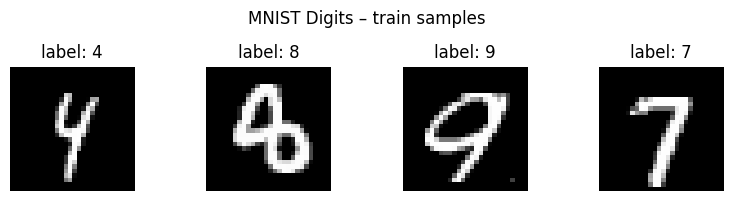


--- FASHION DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



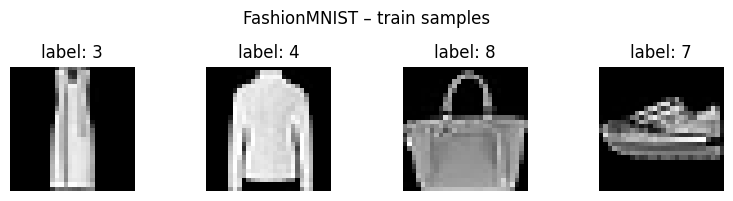

In [16]:
train_digits, val_digits, test_digits = get_mnist_loaders(dataset="mnist", batch_size=128)
show_samples(train_digits, "MNIST Digits – train samples")

train_fashion, val_fashion, test_fashion = get_mnist_loaders(dataset="fashion", batch_size=128)
show_samples(train_fashion, "FashionMNIST – train samples")

# General Helpers

## Noise Schedule

Reuses the standard [linear beta schedule from DDPM](https://arxiv.org/pdf/2006.11239.pdf#page=14); was initially implemented with explanations in DDPM & DDIM notebook

In [17]:
class NoiseSchedule:
    """Precomputes all diffusion constants for a linear beta schedule and provides forward step"""

    def __init__(
        self,
        T: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 0.02,
        device: str = "cpu",
    ):
        self.T = T
        self.device = device

        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alpha_bar = alpha_bar
        self.alpha_bar_prev = alpha_bar_prev

        self.sqrt_alpha_bar = torch.sqrt(alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / alphas)

        self.posterior_variance = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
        self.posterior_log_variance = torch.log(self.posterior_variance.clamp(min=1e-20))

    def _extract(self, arr: torch.Tensor, t: torch.Tensor, x_shape: tuple) -> torch.Tensor:
        """Gather values from `arr` at indices `t` and reshape for broadcasting over (B, C, H, W)"""
        batch_size = t.shape[0]
        out = arr.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: Optional[torch.Tensor] = None):
        """Forward diffusion: sample x_t given x_0"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self._extract(self.sqrt_alpha_bar, t, x0.shape)
        sqrt_1_ab = self._extract(self.sqrt_one_minus_alpha_bar, t, x0.shape)
        return sqrt_ab * x0 + sqrt_1_ab * noise, noise


schedule = NoiseSchedule(T=1000, device=device)

## Shared Building Blocks

Same components sinusoidal timestep embeddings, residual blocks with additive time conditioning, and self-attention at the bottleneck from DDPM & DDIM notebook

In [18]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for the diffusion timestep"""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    """Residual block with time conditioning via additive bias"""
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.skip_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]  # broadcast (B, C) -> (B, C, 1, 1)
        h = self.block2(h)
        return h + self.skip_conv(x)


class SelfAttention(nn.Module):
    """
    Single-head self-attention over spatial dimensions
    Applied at the bottleneck (7×7) where O(n²) cost is manageable
    """
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)

## Visualization

In [19]:
def show_grid(images, title="", nrow=10):
    """Show a grid of images (expected in [-1, 1])"""
    images = (images.clamp(-1, 1) + 1) / 2
    grid = torchvision.utils.make_grid(images, nrow=nrow, padding=1)
    plt.figure(figsize=(nrow * 1.2, max(1, len(images) // nrow) * 1.2))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

def show_cfg_sweep(sample_fn, classes, w_values, n_per_class=8,
                          pad=0, title="CFG Strength Sweep"):
    """Visualize how guidance scale w affects generation for each class"""
    nrows = len(w_values)
    ncols = len(classes)

    fig_w = max(12, ncols * 3.1 + 1.2)
    fig_h = max(6,  nrows * 1.45)

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols + 1,
        width_ratios=[0.55] + [1.0] * ncols,
        wspace=0.05,
        hspace=0.20
    )
    for j, c in enumerate(classes):
        ax_title = fig.add_subplot(gs[0, j + 1])
        ax_title.set_title(f"class {c}", fontsize=11, pad=6)
        ax_title.axis("off")

    for i, w in enumerate(w_values):
        ax_label = fig.add_subplot(gs[i, 0])
        ax_label.axis("off")
        ax_label.text(
            0.98, 0.5, f"w={w}",
            ha="right", va="center",
            fontsize=12, fontweight="bold"
        )

        for j, c in enumerate(classes):
            ax = fig.add_subplot(gs[i, j + 1])

            imgs = sample_fn(class_label=c, w=w, n=n_per_class)
            grid = torchvision.utils.make_grid(
                (imgs.clamp(-1, 1) + 1) / 2,
                nrow=n_per_class,
                padding=pad
            )

            ax.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

    fig.suptitle(title, fontsize=15, y=0.995)
    fig.subplots_adjust(left=0.02, right=0.995, top=0.94, bottom=0.02)
    plt.show()

# Classifier-Free Guidance

The core idea from [Ho & Salimans (2022)](https://arxiv.org/abs/2207.12598) is simple: instead of training a separate classifier to guide diffusion, we train a single model that can act as both conditional and unconditional denoiser.

During training, we randomly drop the class label with probability `p_uncond` (typically 10–20%), replacing it with a learnable "null" token. This teaches the network to predict noise both with and without class information.

At inference, we run two forward passes per timestep and interpolate:

$$\hat{\epsilon}_w = (1 + w) \cdot \epsilon_\theta(x_t, t, c) - w \cdot \epsilon_\theta(x_t, t, \varnothing)$$

* $\epsilon_\theta(x_t, t, c)$ is the model’s **conditional** noise estimate: "what noise should be removed from (x_t) at timestep (t) *if we want class (c)*?".
* $\epsilon_\theta(x_t, t, \varnothing)$ is the model’s **unconditional** noise estimate: "what noise should be removed from (x_t) at timestep (t) *with no class information*?".
  In this implementation, $\varnothing$ is represented by a learnable `NULL_CLASS` token that the model sees during training via label dropout.
* $w \ge 0$ is the **guidance scale** controlling how strongly we enforce the conditioning.

When `w=0` we get standard conditional generation. As `w` grows the model pushes harder toward the conditioned class, improving fidelity but reducing diversity. This is the classic quality-diversity tradeoff that all guidance methods share.

CFG itself is agnostic about *how* you inject the class signal into the U-Net, it only cares that the model can run in both conditional and unconditional modes. The conditioning mechanism is a separate design choice, so the fundamental question is: **given a discrete class label $c \in \{0, ..., K-1\}$, how do we tell the U-Net which class to generate?**

### Approach 1: Naive one-hot concatenation

The most obvious idea is to encode the class as a one-hot vector of length $K$, broadcast it spatially to match the image resolution, and concatenate it as extra input channels.

**Procedure**: For class $c$ in $K$ classes, create a one-hot vector $\mathbf{e}_c \in \mathbb{R}^K$, repeat it to shape $(K, H, W)$, and concatenate with the noisy image to get input of shape $(1 + K, H, W)$.

**Where it's injected**: Only at the input, before `conv_in`.

**Problems**: Terrible scaling, like for ImageNet ($K$=1000) you'd add 1000 extra input channels. Each channel is binary (0 or 1) so it carries very little information per parameter. The model has to learn from scratch that "channel 7 being 1 means digit 7", and there's no learned representation of what classes mean.

### Approach 2: Learned spatial map concatenation (c_map)

Instead of one-hot vectors, learn an embedding per class that gets reshaped into a spatial map and concatenated as a single extra channel.

**Procedure**: `nn.Embedding(K, H×W)` maps each class to a learned vector of length $H \times W = 784$. This is reshaped to $(1, H, W)$ and concatenated with the image → input shape $(2, H, W)$.

**Where it's injected**: Only at the input, before `conv_in`.

**Why it's better than one-hot**: The embedding is learned — the model can represent class similarities and structure in the embedding space. Only 1 extra channel regardless of $K$.

**Problems**: It is still wasteful to learn 784 parameters per class to encode what is fundamentally a low-dimensional class identity signal. The spatial structure of the embedding is arbitrary since class identity has no inherent 28×28 layout. The conditioning enters only at the input resolution and the model must propagate it through all layers implicitly. It also changes the input channel count, so we can't reuse a pretrained unconditional model.

### Approach 3: Timestep-style additive injection ✓ (first implementation)

This is the standard approach used in most practical implementations including [Ho & Salimans (2022)](https://arxiv.org/abs/2207.12598) and [Nichol & Dhariwal (2021)](https://arxiv.org/abs/2102.09672). The timestep $t$ already has a conditioning pathway into every ResBlock (sinusoidal embedding → MLP → additive bias). Why not reuse the exact same mechanism for the class?

**Procedure**: Embed the class via `nn.Embedding(K, dim)`, project through a small MLP, and add it to the time embedding. The combined `(time + class)` vector then enters every ResBlock through the existing `time_proj` layer.

**Where it's injected**: At every ResBlock in both encoder and decoder, through the same `time_proj` linear layer, to make the class signal a global bias that modulates feature maps at all resolutions.

**Why it's good**: Zero architectural changes to the U-Net body. The existing `time_proj` in each ResBlock handles both time and class. We just add one embedding + MLP on top and sum the result with the time embedding. We can take a pretrained unconditional model and fine-tune it with class conditioning by only adding the class embedding parameters. It also scales to any number of classes, because the embedding is low-dimensional (like 128–256 should be enough), regardless of $K$.

**Limitation**: The same class signal is added uniformly across all spatial positions. The model can't easily attend to the class differently at different locations. For simple tasks like MNIST this is perfectly fine, but for complex tasks (text-to-image, multi-object scenes) the model needs more spatial flexibility.

### Approach 4: Adaptive Group Normalization (AdaGN)

Used in [Dhariwal & Nichol (2021)](https://arxiv.org/abs/2105.05233) (the "Diffusion Beats GANs" paper). Instead of just adding a bias, predict both **scale** and **shift** parameters from the conditioning, and apply them inside the normalization:

$$\text{AdaGN}(h, y) = \gamma(y) \cdot \text{GroupNorm}(h) + \beta(y)$$

**Procedure**: The conditioning vector (time + class embedding) is projected to predict $2C$ values per ResBlock: $C$ scale factors $\gamma$ and $C$ shift biases $\beta$. After GroupNorm normalizes the features, it's rescaled by $\gamma$ and shifted by $\beta$.

**Where it's injected**: Inside every ResBlock, replacing the simple additive bias with a scale-shift mechanism in the normalization layer.

**Why it's better**: Strictly more expressive than additive injection, as it can modulate feature magnitudes (via scale), not just shift them. This is the same idea as AdaIN in StyleGAN ([Karras et al., 2019](https://arxiv.org/abs/1812.04948)) and FiLM conditioning ([Perez et al., 2018](https://arxiv.org/abs/1709.07871)). The scale parameter lets the model amplify or suppress entire feature channels based on the class, giving finer-grained control. In our `ResBlock`, the change would look like replacing `h = h + time_proj(t_emb)` with `scale, shift = time_proj(t_emb).chunk(2); h = scale * GroupNorm(h) + shift`.

**Limitation**: Still a global signal like a previous approach. Same scale/shift applied everywhere spatially. More parameters than simple addition (2× the projection size). However, for MNIST the extra expressiveness is unlikely to matter.

### Approach 5: Cross-attention ✓ (second implementation)

Used in [Rombach et al. (2022)](https://arxiv.org/abs/2112.10752) for Stable Diffusion. The conditioning is treated as a key-value sequence that spatial features attend to via standard cross-attention.

**Procedure**: The class label is embedded into a context vector and projected to shape $(B, L, d)$ where $L$ is the sequence length (1 for a single class token, variable for text). At each resolution level, spatial features $(B, C, H, W)$ are reshaped to $(B, HW, C)$ and used as **queries**. The context provides **keys** and **values**. Standard multi-head attention computes which spatial positions should attend to which parts of the conditioning.

**Where it's injected**: Dedicated cross-attention layers after ResBlocks, typically at every resolution level (or at least at the middle resolutions).

**Why it's the most expressive**: The model learns where spatially to use the conditioning; different spatial positions can attend differently to the class signal. This is essential for text-to-image where "a cat on the left and a dog on the right" requires spatially-varying conditioning. For class conditioning with a single token the benefit is modest, but the mechanism generalises naturally to arbitrary-length text prompts. This is why Stable Diffusion uses it, because the same architecture handles CLIP text embeddings of any length.

**Limitation**: More parameters and compute (extra QKV projections + attention per layer). For a single class label on MNIST, it's overkill. We're paying the cost of full attention machinery to compute what is essentially a position-dependent weighting of one vector.

In [20]:
NUM_CLASSES = 10
NULL_CLASS = NUM_CLASSES # index 10 = unconditional token

## U-Net with Additive Class Injection

The standard approach from the CFG paper(https://arxiv.org/abs/2207.12598). We add a class embedding MLP that mirrors the time embedding MLP, sum their outputs, and feed the combined vector into every ResBlock through the existing `time_proj` pathway.

The U-Net body is identical to  DDPM & DDIM noteboo: same channel counts, same ResBlocks, same `conv_in(1 channel)`. The only addition is a class embedding + MLP that produces a vector of the same dimensionality as the time embedding.

In [21]:
class CFGUNetAdditive(nn.Module):
    """U-Net with class conditioning via additive embedding injection"""
    def __init__(self, in_ch: int = 1, base_ch: int = 64, time_dim: int = 256,
                 num_classes: int = 10, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4  # 64, 128, 256

        # time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # class embedding MLP: Embedding → Linear → SiLU → Linear
        # +1 for the null/unconditional token used during CFG
        self.class_mlp = nn.Sequential(
            nn.Embedding(num_classes + 1, time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # encoder
        self.conv_in = nn.Conv2d(in_ch, ch1, 3, padding=1)

        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)

        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        # bottleneck with self-attention at 7×7
        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_attn = SelfAttention(ch3)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # decoder
        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)

        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)

        # output
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, ch1), nn.SiLU(),
            nn.Conv2d(ch1, 1, 3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor,
                y: torch.Tensor) -> torch.Tensor:
        # time + class embeddings are simply added
        t_emb = self.time_mlp(t) + self.class_mlp(y)

        # forward pass
        h = self.conv_in(x)
        h1 = self.down1_res1(h, t_emb)
        h1 = self.down1_res2(h1, t_emb)
        h = self.down1_pool(h1)

        h2 = self.down2_res1(h, t_emb)
        h2 = self.down2_res2(h2, t_emb)
        h = self.down2_pool(h2)

        h = self.mid_res1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t_emb)

        h = self.up2_upsample(h)
        h = torch.cat([h, h2], dim=1)
        h = self.up2_res1(h, t_emb)
        h = self.up2_res2(h, t_emb)

        h = self.up1_upsample(h)
        h = torch.cat([h, h1], dim=1)
        h = self.up1_res1(h, t_emb)
        h = self.up1_res2(h, t_emb)

        return self.conv_out(h)

In [22]:
# sanity check
_m = CFGUNetAdditive().to(device)
_x = torch.randn(2, 1, 28, 28, device=device)
_t = torch.randint(0, 1000, (2,), device=device)
_y = torch.tensor([3, 7], device=device)
assert _m(_x, _t, _y).shape == (2, 1, 28, 28)
print(f"CFGUNetAdditive params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

CFGUNetAdditive params: 6,300,481


## U-Net with Cross-Attention Conditioning

This is closer to what [Rombach et al. (2022)](https://arxiv.org/abs/2112.10752) use in Latent Diffusion / Stable Diffusion. Instead of a global additive bias, intermediate feature maps attend to a class embedding via cross-attention. The model learns *how* and *where* to use the conditioning signal — the most expressive mechanism on the spectrum.

We inject cross-attention after each pair of ResBlocks (at every resolution level), using the class embedding as key/value context. For a single class token this is more machinery than strictly necessary, but it demonstrates exactly how text-to-image models work (swap the single class token for a sequence of CLIP text embeddings and you have Stable Diffusion's conditioning).

In [23]:
class CrossAttention(nn.Module):
    """
    Cross-attention: spatial features (queries) attend to a context sequence (keys/values)

    For class conditioning the context is just a single token [B, 1, ctx_dim]
    """
    def __init__(self, spatial_ch: int, ctx_dim: int, n_heads: int = 4):
        super().__init__()
        assert spatial_ch % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = spatial_ch // n_heads

        self.norm = nn.GroupNorm(8, spatial_ch)
        self.to_q = nn.Linear(spatial_ch, spatial_ch)
        self.to_kv = nn.Linear(ctx_dim, spatial_ch * 2)
        self.to_out = nn.Linear(spatial_ch, spatial_ch)

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W] spatial features
        context: [B, seq_len, ctx_dim] conditioning sequence
        """
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).permute(0, 2, 1) # [B, HW, C]

        q = self.to_q(h) # [B, HW, C]
        k, v = self.to_kv(context).chunk(2, dim=-1) # [B, seq_len, C] each

        # multi-head reshape [B, n_heads, seq_len, head_dim]
        def rearrange(t):
            return t.view(B, -1, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = map(rearrange, (q, k, v))
        attn = F.scaled_dot_product_attention(q, k, v)
        attn = attn.transpose(1, 2).contiguous().view(B, H * W, C)

        out = self.to_out(attn).permute(0, 2, 1).view(B, C, H, W)
        return x + out # residual


class CFGUNetCrossAttn(nn.Module):
    """U-Net conditioned via cross-attention at each resolution level"""
    def __init__(self, base_ch: int = 64, time_dim: int = 256,
                 ctx_dim: int = 128, num_classes: int = 10, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4
        C = num_classes + 1 # +1 for null token

        # class → context token
        self.class_emb = nn.Sequential(
            nn.Embedding(C, ctx_dim), nn.SiLU(), nn.Linear(ctx_dim, ctx_dim),
        )

        # time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # encoder + cross-attention at each level
        self.conv_in = nn.Conv2d(1, ch1, 3, padding=1)

        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_xattn = CrossAttention(ch1, ctx_dim)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)

        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_xattn = CrossAttention(ch2, ctx_dim)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        # bottleneck self-attention (spatial) + cross-attention (class)
        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_self_attn = SelfAttention(ch3)
        self.mid_xattn = CrossAttention(ch3, ctx_dim)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # decoder + cross-attention at each level
        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.up2_xattn = CrossAttention(ch2, ctx_dim)

        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.up1_xattn = CrossAttention(ch1, ctx_dim)

        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, ch1), nn.SiLU(),
            nn.Conv2d(ch1, 1, 3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor,
                y: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        ctx = self.class_emb(y).unsqueeze(1)

        # encoder
        h = self.conv_in(x)
        h1 = self.down1_res1(h, t_emb)
        h1 = self.down1_res2(h1, t_emb)
        h1 = self.down1_xattn(h1, ctx)
        h = self.down1_pool(h1)

        h2 = self.down2_res1(h, t_emb)
        h2 = self.down2_res2(h2, t_emb)
        h2 = self.down2_xattn(h2, ctx)
        h = self.down2_pool(h2)

        # bottleneck
        h = self.mid_res1(h, t_emb)
        h = self.mid_self_attn(h)
        h = self.mid_xattn(h, ctx)
        h = self.mid_res2(h, t_emb)

        # decoder
        h = self.up2_upsample(h)
        h = torch.cat([h, h2], dim=1)
        h = self.up2_res1(h, t_emb)
        h = self.up2_res2(h, t_emb)
        h = self.up2_xattn(h, ctx)

        h = self.up1_upsample(h)
        h = torch.cat([h, h1], dim=1)
        h = self.up1_res1(h, t_emb)
        h = self.up1_res2(h, t_emb)
        h = self.up1_xattn(h, ctx)

        return self.conv_out(h)

In [24]:
# sanity check
_m = CFGUNetCrossAttn().to(device)
assert _m(torch.randn(2, 1, 28, 28, device=device),
          torch.randint(0, 1000, (2,), device=device),
          torch.tensor([3, 7], device=device)).shape == (2, 1, 28, 28)
print(f"CFGUNetCrossAttn params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

CFGUNetCrossAttn params: 6,564,673


## Training

With probability `p_uncond` (15% in this implementation) we replace the real class label with the null token (`NULL_CLASS=10`). This forces the model to learn both conditional and unconditional denoising within a single set of weights.

In [25]:
def train_cfg_model(model, train_loader, schedule, optimizer,
                    epochs=25, p_uncond=0.15):
    """Train a class-conditional diffusion model with random label dropout for CFG"""
    model.train()
    losses = []

    for epoch in range(1, epochs + 1):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        epoch_loss = 0.0

        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            B = x.size(0)

            # sample random timesteps and noise
            t = torch.randint(0, schedule.T, (B,), device=device)
            noise = torch.randn_like(x)
            x_t, _ = schedule.q_sample(x, t, noise)

            # randomly drop labels
            drop_mask = torch.rand(B, device=device) < p_uncond
            y_cfg = y.clone()
            y_cfg[drop_mask] = NULL_CLASS

            # predict noise
            pred = model(x_t, t, y_cfg)
            loss = F.mse_loss(pred, noise) # standard MSE loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg = epoch_loss / len(train_loader)
        losses.append(avg)
        print(f"  Epoch {epoch}: avg loss = {avg:.4f}")

    return losses

### Train Additive Injection Model

In [26]:
model_additive = CFGUNetAdditive().to(device)
opt_additive = torch.optim.AdamW(model_additive.parameters(), lr=2e-4)
print(f"Additive model: {sum(p.numel() for p in model_additive.parameters()):,} params")

losses_additive = train_cfg_model(model_additive, train_digits, schedule, opt_additive, epochs=25)

Additive model: 6,300,481 params


Epoch 1/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 1: avg loss = 0.0765


Epoch 2/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 2: avg loss = 0.0364


...

  Epoch 23: avg loss = 0.0222


Epoch 24/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 24: avg loss = 0.0220


Epoch 25/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 25: avg loss = 0.0222


### Train Cross-attention Model

In [27]:
model_xattn = CFGUNetCrossAttn().to(device)
opt_xattn = torch.optim.AdamW(model_xattn.parameters(), lr=2e-4)
print(f"Cross-attn model: {sum(p.numel() for p in model_xattn.parameters()):,} params")

losses_xattn = train_cfg_model(model_xattn, train_digits, schedule, opt_xattn, epochs=25)

Cross-attn model: 6,564,673 params


Epoch 1/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 1: avg loss = 0.0743


Epoch 2/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 2: avg loss = 0.0366


...

  Epoch 23: avg loss = 0.0219


Epoch 24/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 24: avg loss = 0.0220


Epoch 25/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 25: avg loss = 0.0221


### Training Curves

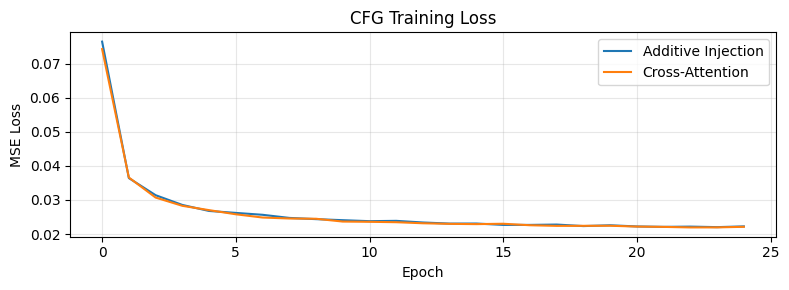

In [28]:
plt.figure(figsize=(8, 3))
plt.plot(losses_additive, label="Additive Injection")
plt.plot(losses_xattn, label="Cross-Attention")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend()
plt.title("CFG Training Loss"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## DDPM Sampling with CFG

Two forward passes per step (conditional + unconditional), then guided combination

In [29]:
@torch.no_grad()
def sample_cfg_ddpm(model, schedule, class_label: int, w: float = 3.0, n: int = 16):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    y_cond = torch.full((n,), class_label, dtype=torch.long, device=device)
    y_uncond = torch.full((n,), NULL_CLASS, dtype=torch.long, device=device)

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((n,), t, dtype=torch.long, device=device)

        # two forward passes: conditional and unconditional
        eps_cond = model(x, t_batch, y_cond)
        eps_uncond = model(x, t_batch, y_uncond)

        # guided noise prediction: ε̂ = (1+w)·ε_cond − w·ε_uncond
        eps = (1 + w) * eps_cond - w * eps_uncond

        # DDPM reverse step
        mean = schedule.sqrt_recip_alpha[t] * (
            x - schedule.betas[t] / schedule.sqrt_one_minus_alpha_bar[t] * eps
        )

        if t > 0:
            sigma = schedule.posterior_variance[t].sqrt()
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean

    return x.clamp(-1, 1)

## DDIM Sampling with CFG

Same CFG formula but using the DDIM update for fewer steps

In [30]:
@torch.no_grad()
def sample_cfg_ddim(model, schedule, class_label: int, w: float = 3.0,
                    n: int = 16, ddim_steps: int = 50, eta: float = 0.0):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    y_cond = torch.full((n,), class_label, dtype=torch.long, device=device)
    y_uncond = torch.full((n,), NULL_CLASS, dtype=torch.long, device=device)

    # sub-sample timesteps uniformly
    step_size = schedule.T // ddim_steps
    timesteps = list(range(0, schedule.T, step_size))[::-1]

    for i, t in enumerate(timesteps):
        t_batch = torch.full((n,), t, dtype=torch.long, device=device)

        eps_cond = model(x, t_batch, y_cond)
        eps_uncond = model(x, t_batch, y_uncond)
        eps = (1 + w) * eps_cond - w * eps_uncond

        ab_t = schedule.alpha_bar[t]
        ab_prev = (schedule.alpha_bar[timesteps[i + 1]]
                   if i + 1 < len(timesteps)
                   else torch.tensor(1.0, device=device))

        # predict x_0
        x0_pred = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1, 1)

        # DDIM update
        sigma = eta * ((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)).sqrt()
        dir_xt = (1 - ab_prev - sigma ** 2).sqrt() * eps
        x = ab_prev.sqrt() * x0_pred + dir_xt
        if sigma > 0:
            x = x + sigma * torch.randn_like(x)

    return x.clamp(-1, 1)

## Experiments

### CFG strength sweep (Additive model)

As `w` increases, images become sharper and more "canonical" for each class, but also more uniform across samples. At very high `w` we may see saturation artifacts. This is the quality-diversity tradeoff described in the [paper](https://arxiv.org/pdf/2207.12598#page=6).

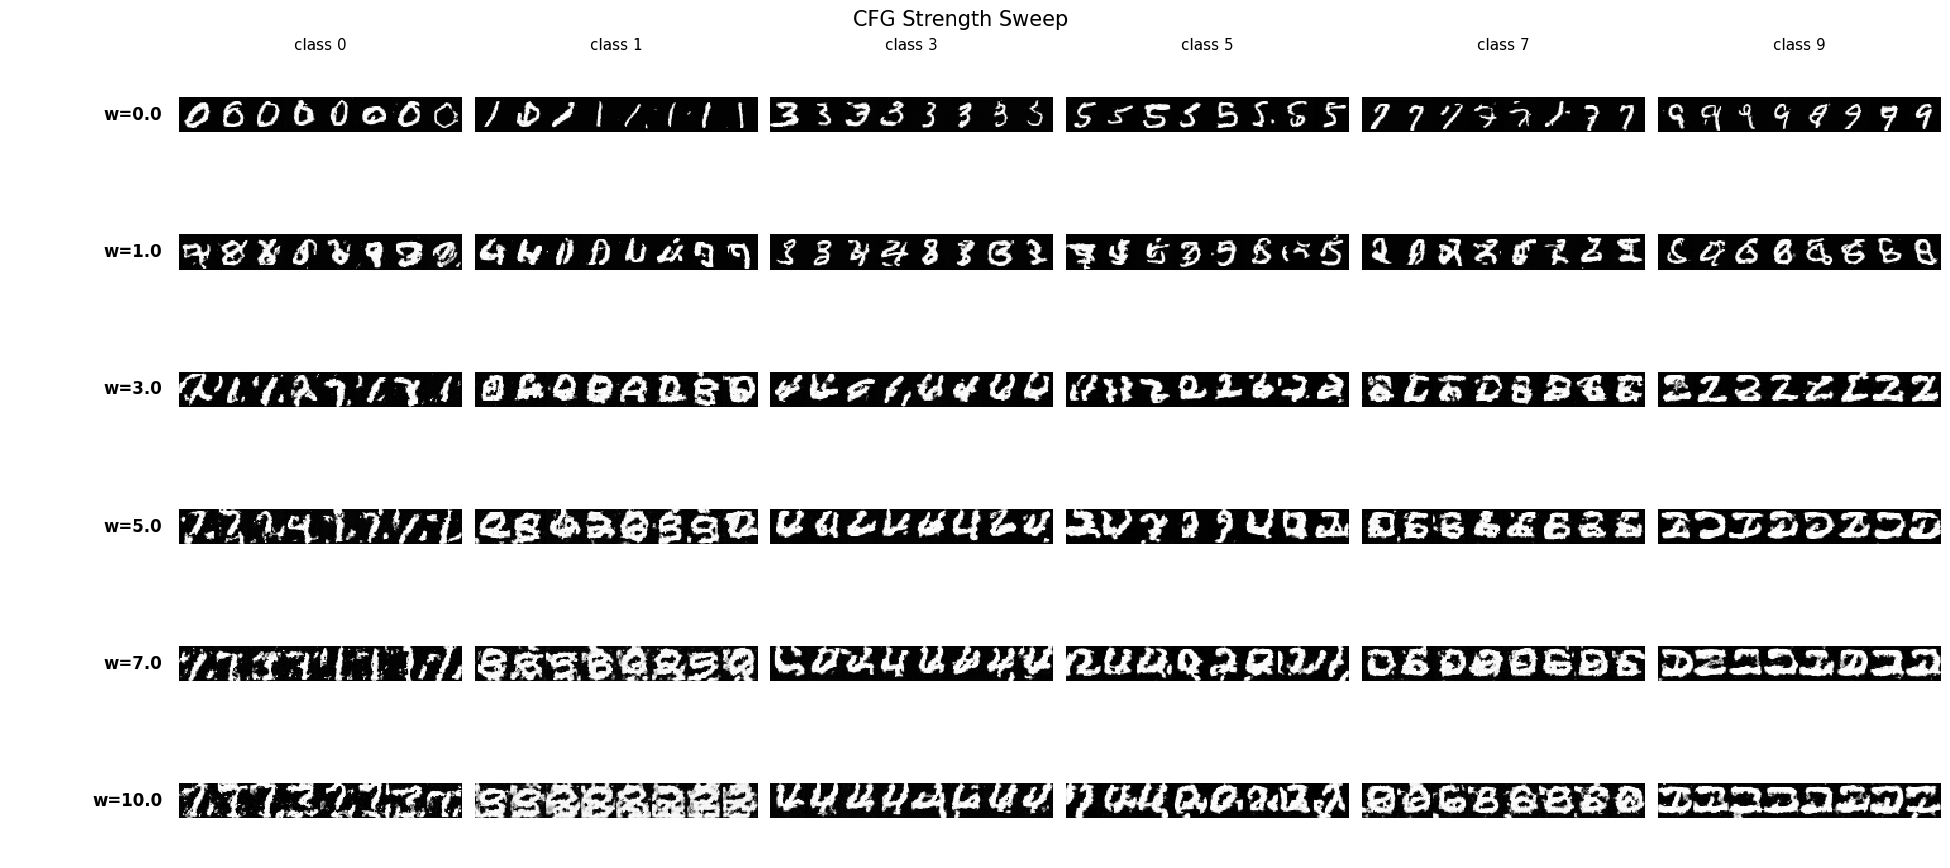

In [45]:
w_values = [0.0, 1.0, 3.0, 5.0, 7.0, 10.0]
classes_to_show = [0, 1, 3, 5, 7, 9]

show_cfg_sweep(
    lambda class_label, w, n: sample_cfg_ddim(
        model_additive, schedule, class_label, w=w, n=n, ddim_steps=50),
    classes=classes_to_show, w_values=w_values, n_per_class=8,
)

### CFG strength sweep (Cross-attention model)

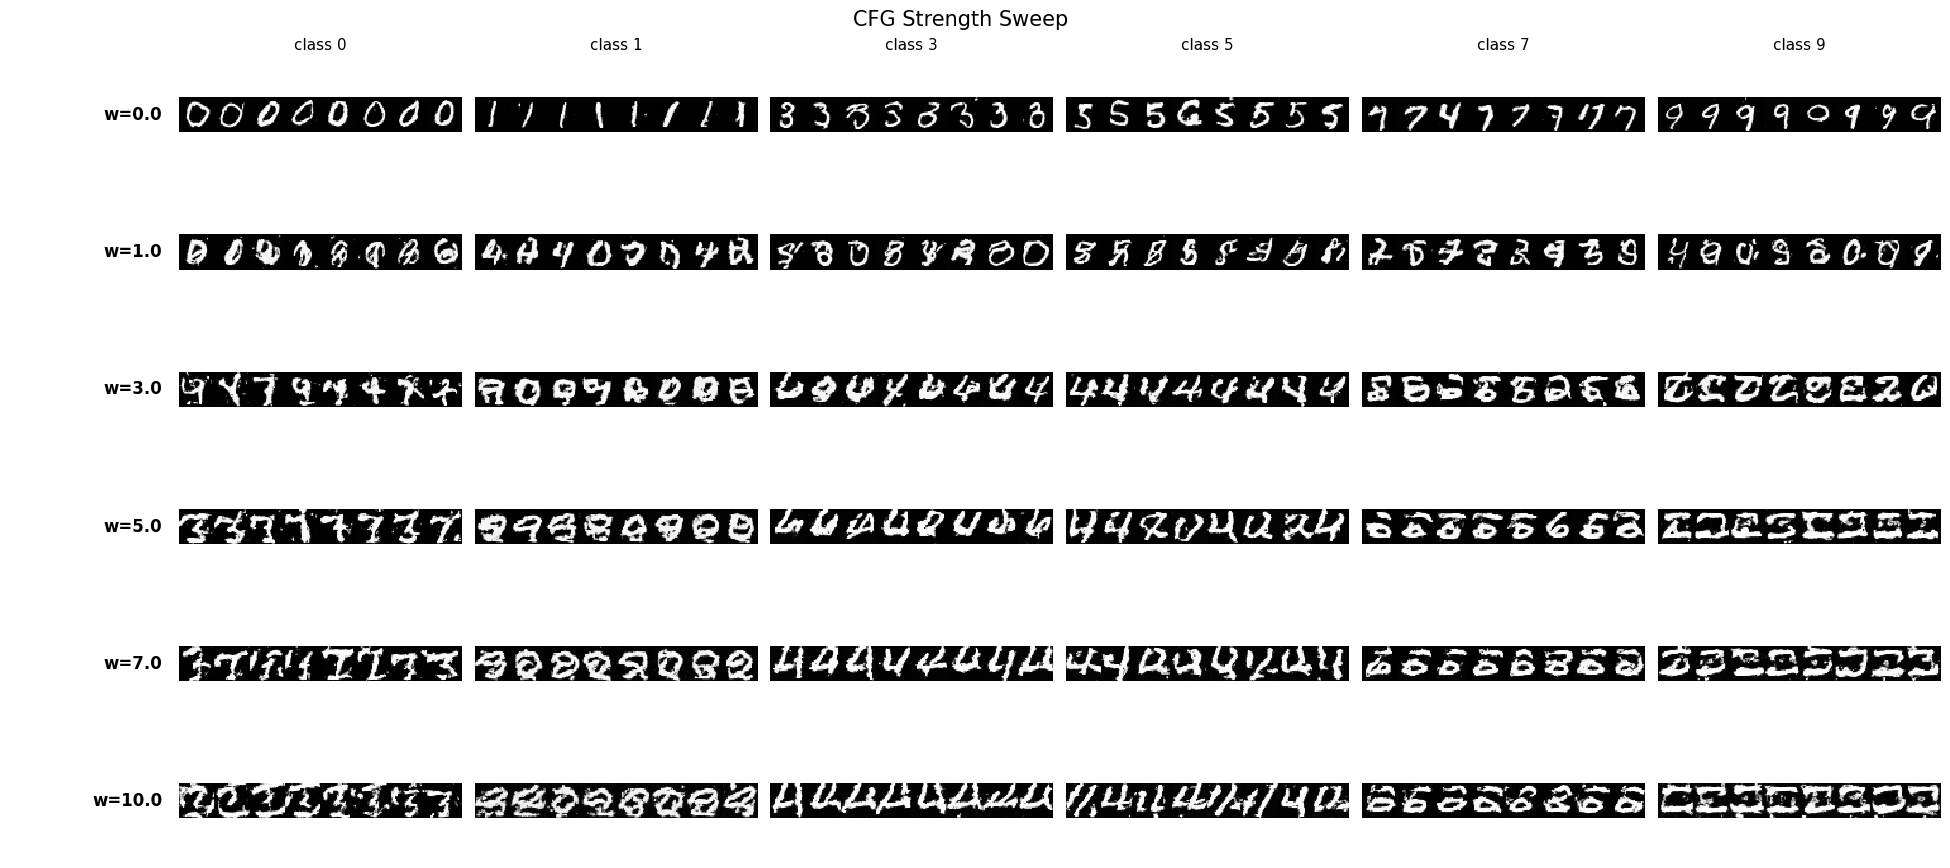

In [46]:
show_cfg_sweep(
    lambda class_label, w, n: sample_cfg_ddim(
        model_xattn, schedule, class_label, w=w, n=n, ddim_steps=50),
    classes=classes_to_show, w_values=w_values, n_per_class=8,
)

### Additive vs Cross-Attention at fixed $w$

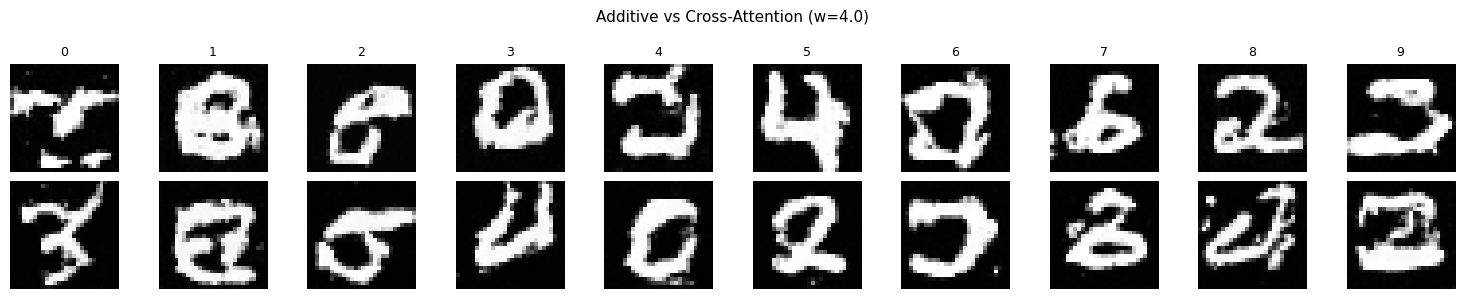

In [33]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
w_fixed = 4.0
for c in range(10):
    imgs_add = sample_cfg_ddim(model_additive, schedule, c, w=w_fixed, n=1)
    imgs_xattn = sample_cfg_ddim(model_xattn, schedule, c, w=w_fixed, n=1)
    axes[0, c].imshow((imgs_add[0, 0].cpu() + 1) / 2, cmap="gray")
    axes[1, c].imshow((imgs_xattn[0, 0].cpu() + 1) / 2, cmap="gray")
    axes[0, c].set_title(str(c), fontsize=9)
    for ax in [axes[0, c], axes[1, c]]:
        ax.axis("off")
axes[0, 0].set_ylabel("Additive", fontsize=9)
axes[1, 0].set_ylabel("XAttn", fontsize=9)
plt.suptitle(f"Additive vs Cross-Attention (w={w_fixed})", fontsize=11)
plt.tight_layout(); plt.show()

### Diversity Measurement

Denerate N samples per class, compute pixel-level variance across them. Higher variance → more diverse outputs. The diversity is expected to drop as guidance strength increases.

  w=  0.0  avg pixel variance: 0.2077
  w=  2.0  avg pixel variance: 0.3074
  w=  5.0  avg pixel variance: 0.2988
  w= 10.0  avg pixel variance: 0.2982
  w= 20.0  avg pixel variance: 0.2763
  w= 50.0  avg pixel variance: 0.2266


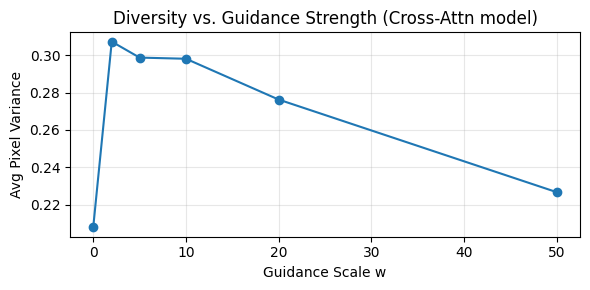

In [37]:
def measure_diversity(sample_fn, class_label, w, n=64):
    imgs = sample_fn(class_label=class_label, w=w, n=n)
    return imgs.view(n, -1).var(dim=0).mean().item()

diversities = {}
for w in [0.0, 2.0, 5.0, 10.0, 20.0, 50.0]:
    d = np.mean([
        measure_diversity(
            lambda class_label, w, n=64: sample_cfg_ddim(model_xattn, schedule, class_label, w=w, n=n),
            c, w
        )
        for c in range(10)
    ])
    diversities[w] = d
    print(f"  w={w:>5.1f}  avg pixel variance: {d:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(list(diversities.keys()), list(diversities.values()), "o-")
plt.xlabel("Guidance Scale w"); plt.ylabel("Avg Pixel Variance")
plt.title("Diversity vs. Guidance Strength (Cross-Attn model)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ControlNet Conditioning

[ControlNet (Zhang et al., 2023)](https://arxiv.org/abs/2302.05543) adds structural control to a pretrained diffusion model. The architecture create a **trainable copy** of the encoder that processes an extra input (Canny edges, depth, poses, etc.), and inject its features back into the frozen decoder through zero-initialized convolutions.

At the start of training, the control branch contributes literally nothing (`0 × features = 0`), so the base model's quality is perfectly preserved. As training progresses, the ControlNet gradually learns to steer the model toward following the structural hint.

For MNIST this is admittedly overkill, but it demonstrates the architecture pattern clearly and can be directly transferred to larger models.

### Canny edge extraction

In [47]:
def extract_canny(images: torch.Tensor, low: int = 50, high: int = 150) -> torch.Tensor:
    """
    Extract Canny edges from a batch of images in [-1, 1]
    Returns edge maps in [-1, 1] (same range as the images)
    """
    imgs_np = ((images + 1) / 2 * 255).clamp(0, 255).byte().cpu().numpy()
    edges = []
    for img in imgs_np:
        e = cv2.Canny(img.squeeze(), low, high)
        edges.append(e)
    edges = np.stack(edges)
    edges_t = torch.from_numpy(edges).float().unsqueeze(1) / 255.0 # [0, 1]
    return (edges_t * 2 - 1).to(images.device) # → [-1, 1]

## ControlNet Architecture

The encoder is a copy of the pretrained additive CFG model. The clone processes the Canny edge hint and injects features at each skip connection level via zero convolutions.

In [48]:
class ZeroConv(nn.Module):
    """1×1 convolution initialized to zero"""
    def __init__(self, ch: int):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 1)
        nn.init.zeros_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class ControlNetWrapper(nn.Module):
    """
    ControlNet wrapper around a frozen CFGUNetAdditive base model

    Trainable: control encoder + zero convs only.
    Frozen: entire base CFGUNetAdditive.
    """
    def __init__(self, base_model: CFGUNetAdditive, base_ch: int = 64,
                 time_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4
        self.base = base_model

        # freeze the base model
        for p in self.base.parameters():
            p.requires_grad = False

        # control encoder processes the Canny edge hint
        self.ctrl_time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.ctrl_conv_in = nn.Conv2d(1, ch1, 3, padding=1) # hint has 1 channel

        self.ctrl_down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.ctrl_down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.ctrl_down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)

        self.ctrl_down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.ctrl_down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.ctrl_down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        self.ctrl_mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.ctrl_mid_attn = SelfAttention(ch3)
        self.ctrl_mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # one zero convolutions per injection point
        self.zero_conv1 = ZeroConv(ch1) # skip-1 level (28×28)
        self.zero_conv2 = ZeroConv(ch2) # skip-2 level (14×14)
        self.zero_conv_mid = ZeroConv(ch3) # bottleneck (7×7)

    def forward(self, x: torch.Tensor, t: torch.Tensor,
                y: torch.Tensor, hint: torch.Tensor) -> torch.Tensor:
        """
        x:    noisy image     [B, 1, 28, 28]
        t:    timestep         [B]
        y:    class label      [B]
        hint: Canny edge map   [B, 1, 28, 28]
        """
        # control branch (trainable)
        ct_emb = self.ctrl_time_mlp(t)

        ch = self.ctrl_conv_in(hint)
        ch1_feat = self.ctrl_down1_res1(ch, ct_emb)
        ch1_feat = self.ctrl_down1_res2(ch1_feat, ct_emb)
        ch = self.ctrl_down1_pool(ch1_feat)

        ch2_feat = self.ctrl_down2_res1(ch, ct_emb)
        ch2_feat = self.ctrl_down2_res2(ch2_feat, ct_emb)
        ch = self.ctrl_down2_pool(ch2_feat)

        ch = self.ctrl_mid_res1(ch, ct_emb)
        ch = self.ctrl_mid_attn(ch)
        ch_mid = self.ctrl_mid_res2(ch, ct_emb)

        # base model forward with injected control features (frozen)
        # time + class embedding (base model's additive injection)
        t_emb = self.base.time_mlp(t) + self.base.class_mlp(y)

        # base encoder with control injection at skip connections
        h = self.base.conv_in(x) # [B, 64, 28, 28]

        h1 = self.base.down1_res1(h, t_emb)
        h1 = self.base.down1_res2(h1, t_emb)
        h1 = h1 + self.zero_conv1(ch1_feat) # ← inject control
        h = self.base.down1_pool(h1)

        h2 = self.base.down2_res1(h, t_emb)
        h2 = self.base.down2_res2(h2, t_emb)
        h2 = h2 + self.zero_conv2(ch2_feat) # ← inject control
        h = self.base.down2_pool(h2)

        # base bottleneck + control
        h = self.base.mid_res1(h, t_emb)
        h = self.base.mid_attn(h)
        h = self.base.mid_res2(h, t_emb)
        h = h + self.zero_conv_mid(ch_mid) # ← inject control

        # base decoder (frozen, uses modified skip connections)
        h = self.base.up2_upsample(h)
        h = torch.cat([h, h2], dim=1)
        h = self.base.up2_res1(h, t_emb)
        h = self.base.up2_res2(h, t_emb)

        h = self.base.up1_upsample(h)
        h = torch.cat([h, h1], dim=1)
        h = self.base.up1_res1(h, t_emb)
        h = self.base.up1_res2(h, t_emb)

        return self.base.conv_out(h)

## Training

Only the control encoder + zero convs are trainable. The base model stays completely frozen.

In [50]:
controlnet = ControlNetWrapper(model_additive).to(device)
trainable = [p for p in controlnet.parameters() if p.requires_grad]
opt_ctrl = torch.optim.AdamW(trainable, lr=2e-4)
print(f"ControlNet trainable params: {sum(p.numel() for p in trainable):,}")
print(f"Base (frozen) params:        {sum(p.numel() for p in model_additive.parameters()):,}")

losses_ctrl = []
controlnet.train()

for epoch in range(1, 21):
    pbar = tqdm(train_digits, desc=f"ControlNet Epoch {epoch}/20", leave=False)
    epoch_loss = 0.0

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        B = x.size(0)

        # Canny edges extraction
        hint = extract_canny(x)

        t = torch.randint(0, schedule.T, (B,), device=device)
        noise = torch.randn_like(x)
        x_t, _ = schedule.q_sample(x, t, noise)

        # label dropout for CFG compatibility
        drop = torch.rand(B, device=device) < 0.15
        y_cfg = y.clone()
        y_cfg[drop] = NULL_CLASS

        pred = controlnet(x_t, t, y_cfg, hint)
        loss = F.mse_loss(pred, noise)

        opt_ctrl.zero_grad()
        loss.backward()
        opt_ctrl.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = epoch_loss / len(train_digits)
    losses_ctrl.append(avg)
    print(f"  Epoch {epoch}: loss = {avg:.4f}")

ControlNet trainable params: 3,671,424
Base (frozen) params:        6,300,481


ControlNet Epoch 1/20:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 1: loss = 0.0165


ControlNet Epoch 2/20:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 2: loss = 0.0151


...

  Epoch 18: loss = 0.0141


ControlNet Epoch 19/20:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 19: loss = 0.0141


ControlNet Epoch 20/20:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 20: loss = 0.0141


### Training Curve

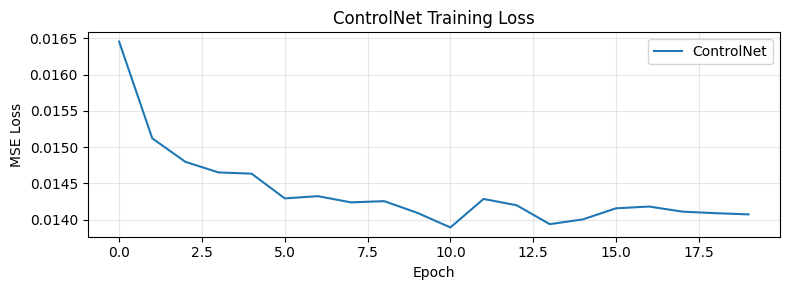

In [51]:
plt.figure(figsize=(8, 3))
plt.plot(losses_ctrl, label="ControlNet")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend()
plt.title("ControlNet Training Loss"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Sampling

In [52]:
@torch.no_grad()
def sample_controlnet(controlnet, schedule, hint_images: torch.Tensor,
                      class_label: int, w: float = 3.0, ddim_steps: int = 50):
    """Generate images guided by Canny edges + class label using DDIM + CFG"""
    controlnet.eval()
    n = hint_images.size(0)
    hints = extract_canny(hint_images)

    x = torch.randn(n, 1, 28, 28, device=device)
    y_cond = torch.full((n,), class_label, dtype=torch.long, device=device)
    y_uncond = torch.full((n,), NULL_CLASS, dtype=torch.long, device=device)

    step_size = schedule.T // ddim_steps
    timesteps = list(range(0, schedule.T, step_size))[::-1]

    for i, t in enumerate(timesteps):
        t_batch = torch.full((n,), t, dtype=torch.long, device=device)

        eps_cond = controlnet(x, t_batch, y_cond, hints)
        eps_uncond = controlnet(x, t_batch, y_uncond, hints)
        eps = (1 + w) * eps_cond - w * eps_uncond

        ab_t = schedule.alpha_bar[t]
        ab_prev = (schedule.alpha_bar[timesteps[i + 1]]
                   if i + 1 < len(timesteps)
                   else torch.tensor(1.0, device=device))

        x0_pred = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1, 1)
        dir_xt = (1 - ab_prev).sqrt() * eps
        x = ab_prev.sqrt() * x0_pred + dir_xt

    return x.clamp(-1, 1)

## Experiments

We take real test images, extract their Canny edges, then generate new images conditioned on those edges plus a (possibly different) class label. The question: does the generated image follow the structural layout of the edges while looking like the target digit?

### Fixed Class, Varying Edges

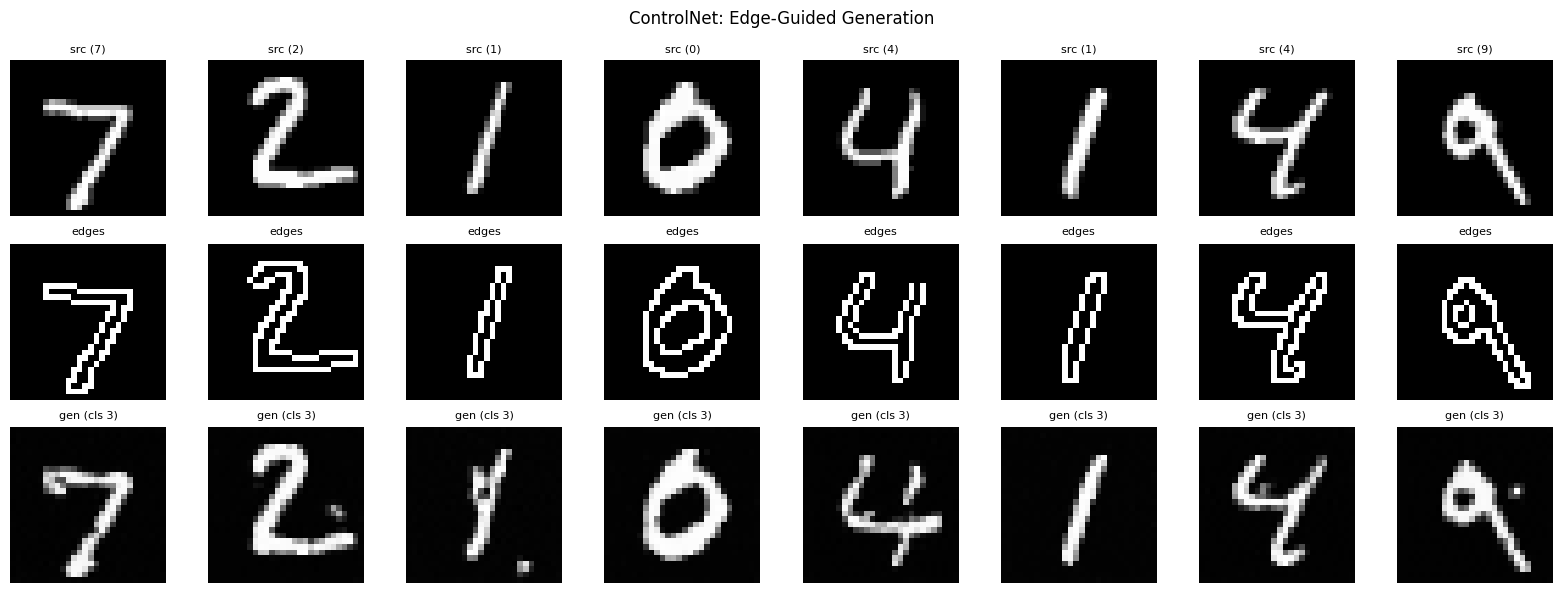

In [53]:
test_batch, test_labels = next(iter(test_digits))
source_imgs = test_batch[:8].to(device)
canny_maps = extract_canny(source_imgs)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow((source_imgs[i, 0].cpu() + 1) / 2, cmap="gray")
    axes[0, i].set_title(f"src ({test_labels[i].item()})", fontsize=8)
    axes[1, i].imshow((canny_maps[i, 0].cpu() + 1) / 2, cmap="gray")
    axes[1, i].set_title("edges", fontsize=8)

target_class = 3
generated = sample_controlnet(controlnet, schedule, source_imgs,
                              class_label=target_class, w=4.0)
for i in range(8):
    axes[2, i].imshow((generated[i, 0].cpu() + 1) / 2, cmap="gray")
    axes[2, i].set_title(f"gen (cls {target_class})", fontsize=8)

for ax in axes.flat:
    ax.axis("off")
axes[0, 0].set_ylabel("Source", fontsize=9)
axes[1, 0].set_ylabel("Canny", fontsize=9)
axes[2, 0].set_ylabel("ControlNet", fontsize=9)
plt.suptitle("ControlNet: Edge-Guided Generation", fontsize=12)
plt.tight_layout(); plt.show()

### Fixed Edges, Varying Class

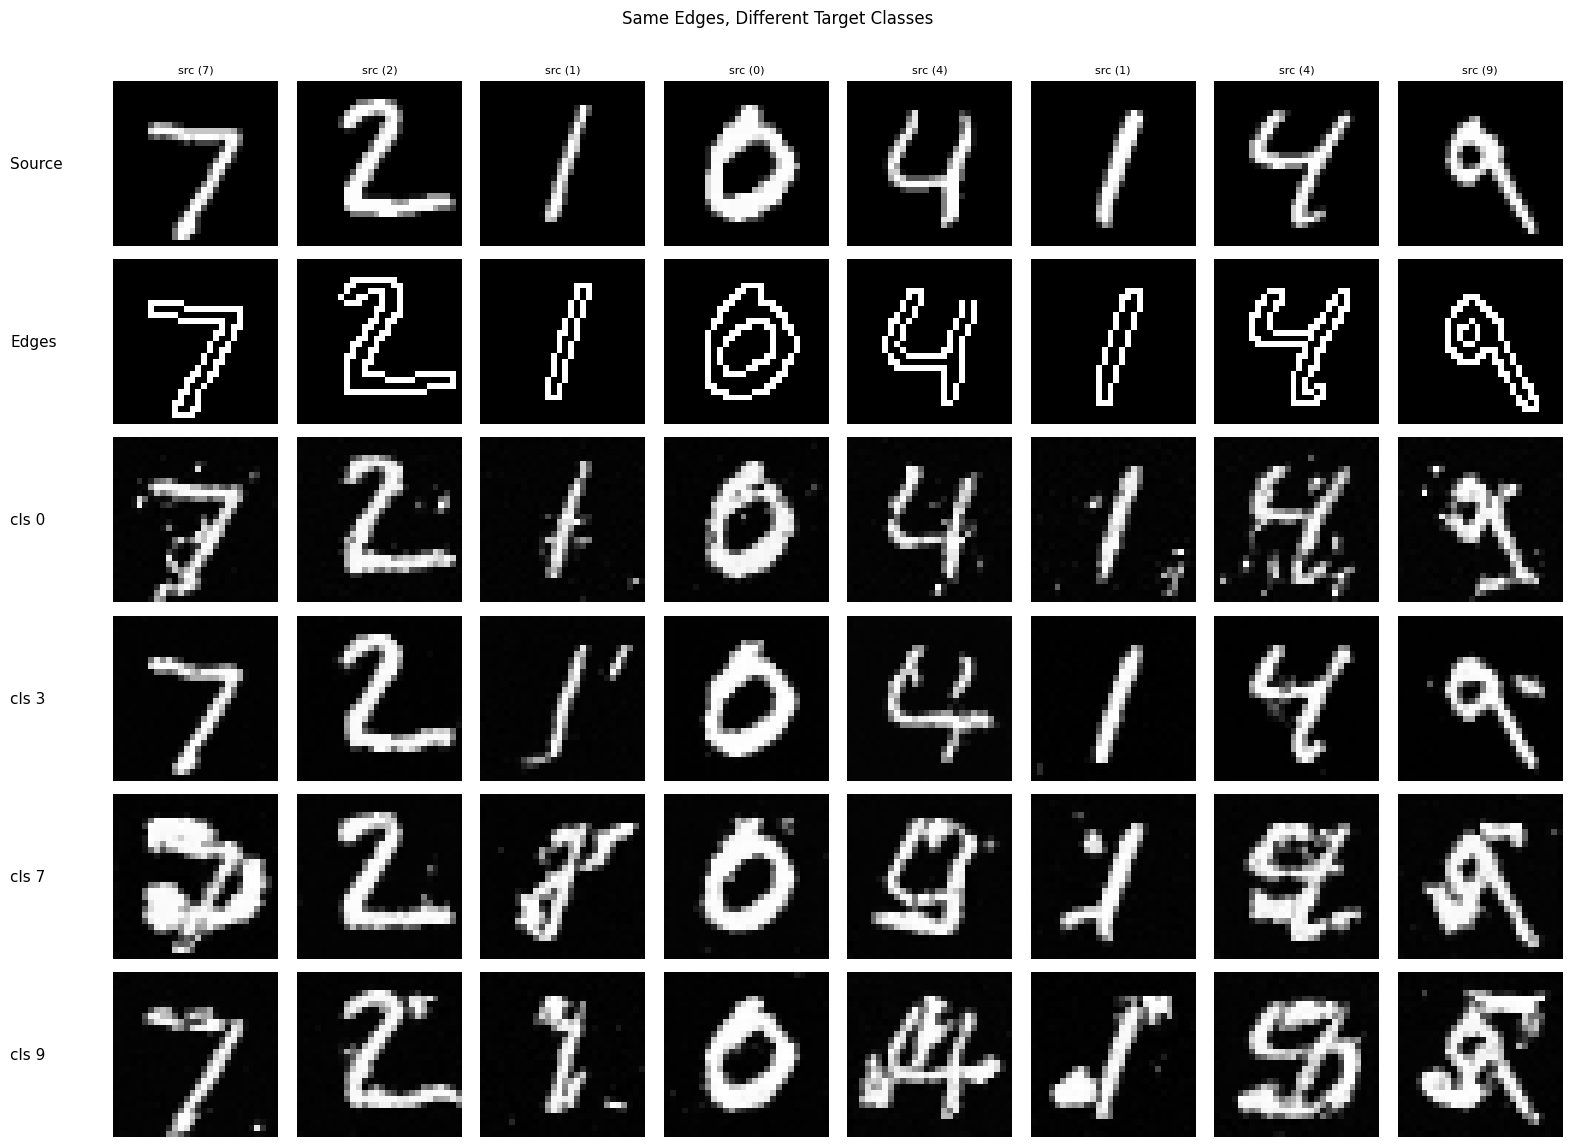

In [67]:
fig, axes = plt.subplots(6, 8, figsize=(16, 12))

for i in range(8):
    axes[0, i].imshow((source_imgs[i, 0].cpu() + 1) / 2, cmap="gray")
    axes[0, i].set_title(f"src ({test_labels[i].item()})", fontsize=8)
    axes[1, i].imshow((canny_maps[i, 0].cpu() + 1) / 2, cmap="gray")
for row, tc in enumerate([0, 3, 7, 9]):
    gen = sample_controlnet(controlnet, schedule, source_imgs, class_label=tc, w=4.0)
    for i in range(8):
        axes[row + 2, i].imshow((gen[i, 0].cpu() + 1) / 2, cmap="gray")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

row_labels = ["Source", "Edges", "cls 0", "cls 3", "cls 7", "cls 9"]
fig.suptitle("Same Edges, Different Target Classes", fontsize=12, y=0.98)
fig.subplots_adjust(left=0.08, right=0.995, top=0.92, bottom=0.04, wspace=0.02, hspace=0.08)
fig.canvas.draw()
for r, label in enumerate(row_labels):
    bbox = axes[r, 0].get_position()
    y_center = (bbox.y0 + bbox.y1) / 2
    fig.text(0.02, y_center, label, ha="left", va="center", fontsize=11)

plt.show()

# Classifier Guidance

Before CFG existed, [Dhariwal & Nichol (2021)](https://arxiv.org/abs/2105.05233) showed you can guide diffusion with a separately trained classifier. If you have a classifier $p_\phi(y | x_t)$ that works on noisy inputs, its gradient w.r.t. $x_t$ tells you which direction to push the image to increase the probability of class $y$.

The modified score becomes:

$$\nabla_{x_t} \log p(x_t | y) = \nabla_{x_t} \log p(x_t) + s \cdot \nabla_{x_t} \log p_\phi(y | x_t)$$

In practice we shift the predicted mean at each DDPM step by $s \cdot \sigma^2 \cdot \nabla_{x_t} \log p_\phi(y | x_t)$.

The advantage is that you can use any unconditional diffusion model and add guidance post-hoc, without retraining. The downsides is the need of a separate classifier that handles all noise levels, the gradient computation adds cost per step, and high guidance scales can produce adversarial-looking artifacts (the classifier gradient pushes toward features the classifier cares about, which aren't always the same features humans care about).

## Noise-Aware Classifier

The classifier must handle inputs at all noise levels $t$, so we condition it on the timestep

In [55]:
class NoiseAwareClassifier(nn.Module):
    """
    CNN classifier that takes (x_t, t) and predicts class probabilities
    Trained on noisy images across all diffusion timesteps
    """
    def __init__(self, num_classes: int = 10, time_dim: int = 64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.GroupNorm(8, 32), nn.SiLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.GroupNorm(8, 32), nn.SiLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.SiLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.SiLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Linear(64 * 7 * 7 + time_dim, 256),
            nn.SiLU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        h = self.conv(x).view(x.size(0), -1)
        return self.head(torch.cat([h, t_emb], dim=-1))

### Training

Note: the averaged accuracy across all noise levels won't be great. At high noise (large $t$) the input is nearly pure Gaussian and even a perfect classifier couldn't do much. At low noise (small $t$) accuracy should be decent. The gradient signal matters most in the later (low-noise) sampling steps anyway.

In [56]:
classifier = NoiseAwareClassifier().to(device)
opt_cls = torch.optim.AdamW(classifier.parameters(), lr=3e-4)
print(f"Classifier params: {sum(p.numel() for p in classifier.parameters()):,}")

cls_losses, cls_accs = [], []

for epoch in range(1, 16):
    classifier.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(train_digits, desc=f"Classifier Epoch {epoch}/15", leave=False):
        x, y = x.to(device), y.to(device)
        B = x.size(0)

        # add random noise at random timesteps — classifier must handle all levels
        t = torch.randint(0, schedule.T, (B,), device=device)
        x_t, _ = schedule.q_sample(x, t)

        logits = classifier(x_t, t)
        loss = F.cross_entropy(logits, y)

        opt_cls.zero_grad()
        loss.backward()
        opt_cls.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += B

    avg_loss = total_loss / len(train_digits)
    acc = correct / total
    cls_losses.append(avg_loss)
    cls_accs.append(acc)
    print(f"  Epoch {epoch}: loss={avg_loss:.4f}, acc={acc:.3f}")

Classifier params: 891,562


Classifier Epoch 1/15:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 1: loss=1.3682, acc=0.509


Classifier Epoch 2/15:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 2: loss=1.2360, acc=0.552


...

  Epoch 13: loss=1.1595, acc=0.574


Classifier Epoch 14/15:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 14: loss=1.1627, acc=0.573


Classifier Epoch 15/15:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 15: loss=1.1552, acc=0.577


#### Training Curves

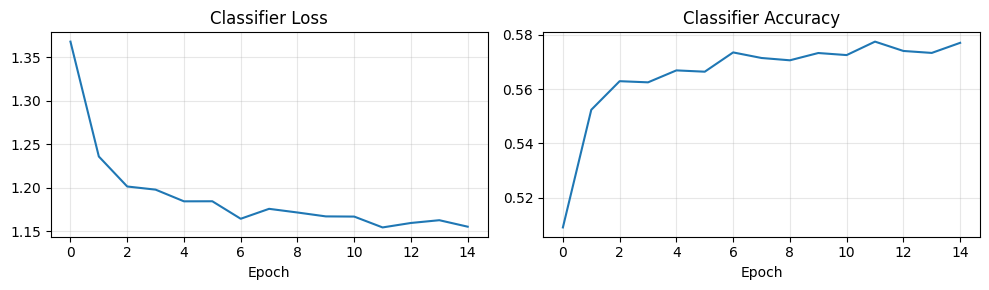

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(cls_losses); ax1.set_title("Classifier Loss"); ax1.set_xlabel("Epoch"); ax1.grid(True, alpha=0.3)
ax2.plot(cls_accs); ax2.set_title("Classifier Accuracy"); ax2.set_xlabel("Epoch"); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Unconditional U-Net

Fully reused from DDPM & DDIM notebook

In [58]:
class UNet(nn.Module):
    def __init__(self, in_ch: int = 1, base_ch: int = 64,
                 time_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # encoder
        self.conv_in = nn.Conv2d(in_ch, ch1, 3, padding=1)

        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)

        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        # bottleneck with self-attention
        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_attn = SelfAttention(ch3)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # decoder
        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)

        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)

        # output
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, ch1), nn.SiLU(),
            nn.Conv2d(ch1, in_ch, 3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        h = self.conv_in(x)
        h1 = self.down1_res1(h, t_emb)
        h1 = self.down1_res2(h1, t_emb)
        h = self.down1_pool(h1)

        h2 = self.down2_res1(h, t_emb)
        h2 = self.down2_res2(h2, t_emb)
        h = self.down2_pool(h2)

        h = self.mid_res1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t_emb)

        h = self.up2_upsample(h)
        h = torch.cat([h, h2], dim=1)
        h = self.up2_res1(h, t_emb)
        h = self.up2_res2(h, t_emb)

        h = self.up1_upsample(h)
        h = torch.cat([h, h1], dim=1)
        h = self.up1_res1(h, t_emb)
        h = self.up1_res2(h, t_emb)

        return self.conv_out(h)

### Training

In [59]:
model_uncond = UNet().to(device)
opt_uncond = torch.optim.AdamW(model_uncond.parameters(), lr=2e-4)
print(f"Unconditional UNet params: {sum(p.numel() for p in model_uncond.parameters()):,}")

losses_uncond = []
model_uncond.train()

for epoch in range(1, 26):
    pbar = tqdm(train_digits, desc=f"Uncond Epoch {epoch}/25", leave=False)
    epoch_loss = 0.0
    for x, y in pbar:
        x = x.to(device)
        B = x.size(0)
        t = torch.randint(0, schedule.T, (B,), device=device)
        noise = torch.randn_like(x)
        x_t, _ = schedule.q_sample(x, t, noise)

        pred = model_uncond(x_t, t)
        loss = F.mse_loss(pred, noise)

        opt_uncond.zero_grad()
        loss.backward()
        opt_uncond.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = epoch_loss / len(train_digits)
    losses_uncond.append(avg)
    print(f"  Epoch {epoch}: loss = {avg:.4f}")

Unconditional UNet params: 6,166,081


Uncond Epoch 1/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 1: loss = 0.0745


Uncond Epoch 2/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 2: loss = 0.0369


...

  Epoch 23: loss = 0.0225


Uncond Epoch 24/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 24: loss = 0.0225


Uncond Epoch 25/25:   0%|          | 0/422 [00:00<?, ?it/s]

  Epoch 25: loss = 0.0225


#### Training Curve

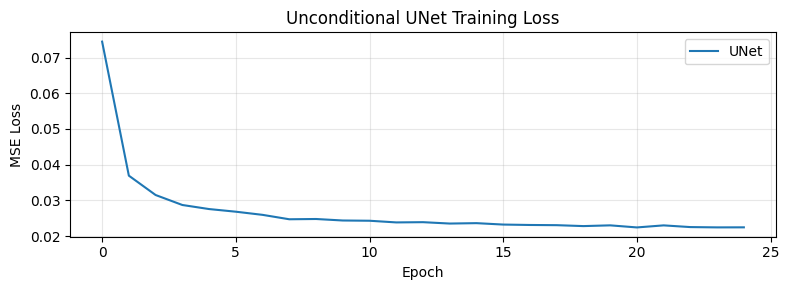

In [60]:
plt.figure(figsize=(8, 3))
plt.plot(losses_uncond, label="UNet")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend()
plt.title("Unconditional UNet Training Loss"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Sampling

In [61]:
@torch.no_grad()
def sample_classifier_guided(model, classifier, schedule,
                              class_label: int, s: float = 5.0, n: int = 16):
    """
    DDPM sampling with classifier guidance
    s: guidance scale (higher means stronger class supervision)
    """
    model.eval()
    classifier.eval()

    x = torch.randn(n, 1, 28, 28, device=device)
    y = torch.full((n,), class_label, dtype=torch.long, device=device)

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((n,), t, dtype=torch.long, device=device)

        # unconditional noise prediction
        eps_pred = model(x, t_batch)

        # DDPM mean
        mean = schedule.sqrt_recip_alpha[t] * (
            x - schedule.betas[t] / schedule.sqrt_one_minus_alpha_bar[t] * eps_pred
        )

        # classifier gradient ∇_{x_t} log p(y | x_t)
        with torch.enable_grad():
            x_in = x.detach().requires_grad_(True)
            logits = classifier(x_in, t_batch)
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[range(n), y].sum()
            grad = torch.autograd.grad(selected, x_in)[0]

        # shift mean μ + s · σ² · ∇ log p(y|x_t)
        mean = mean + s * schedule.betas[t] * grad

        if t > 0:
            sigma = schedule.posterior_variance[t].sqrt()
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean

    return x.clamp(-1, 1)

## Experiments

### Classifier Guidance Scale Sweep

At $s=0$ we get unconditional samples, random digits. As $s$ increases the classifier gradient pushes images toward the target class. Very high $s$ can produce adversarial-looking artifacts because the classifier gradient overpowers the diffusion model's natural image prior.

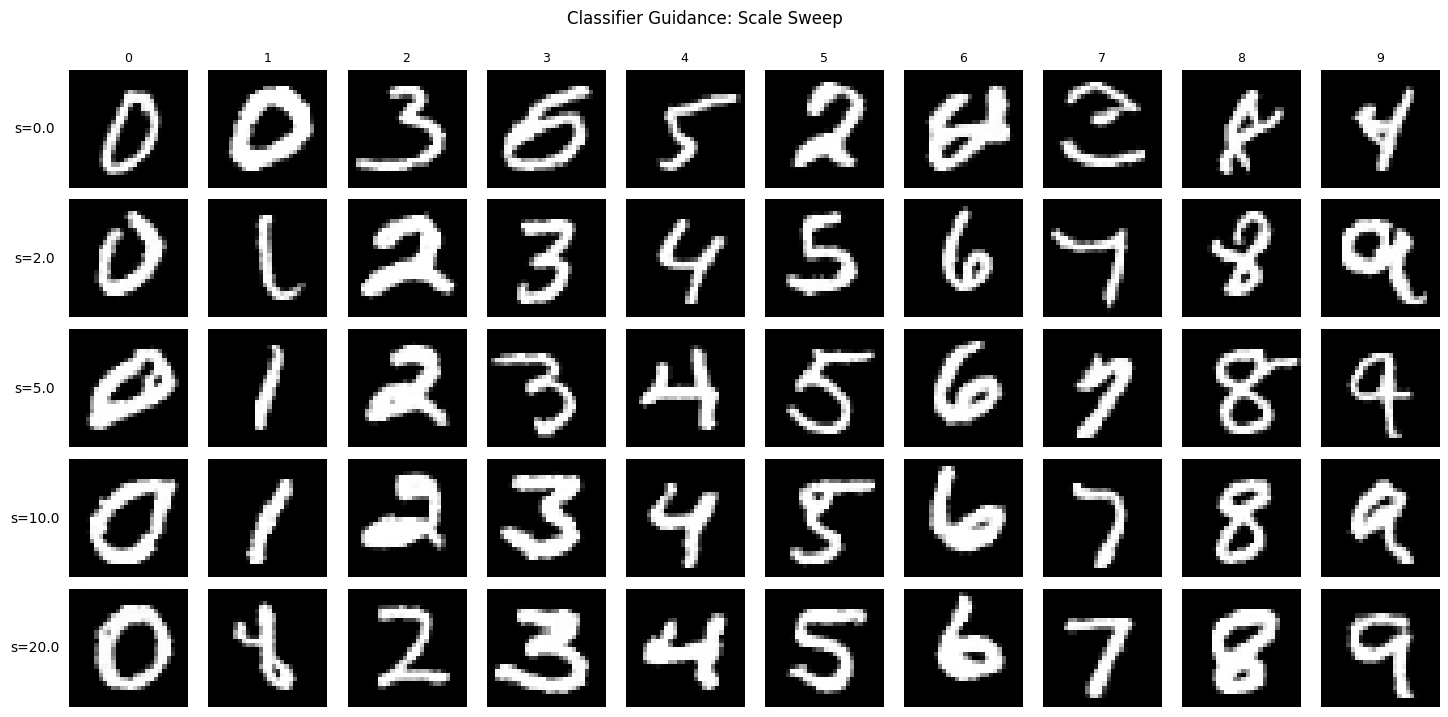

In [68]:
s_values = [0.0, 2.0, 5.0, 10.0, 20.0]
fig, axes = plt.subplots(len(s_values), 10, figsize=(15, len(s_values) * 1.5))

for i, s in enumerate(s_values):
    for c in range(10):
        imgs = sample_classifier_guided(model_uncond, classifier, schedule,
                                        class_label=c, s=s, n=1)
        axes[i, c].imshow((imgs[0, 0].cpu() + 1) / 2, cmap="gray")
        axes[i, c].set_xticks([]); axes[i, c].set_yticks([])
        for spine in axes[i, c].spines.values():
            spine.set_visible(False)
        if i == 0:
            axes[i, c].set_title(str(c), fontsize=9)
    axes[i, 0].set_ylabel(f"s={s}", fontsize=10, rotation=0, labelpad=25, va="center")

plt.suptitle("Classifier Guidance: Scale Sweep", fontsize=12, y=0.98)
fig.subplots_adjust(left=0.07, right=0.995, top=0.90, bottom=0.05, wspace=0.02, hspace=0.10)
plt.show()

### CFG vs Classifier Guidance

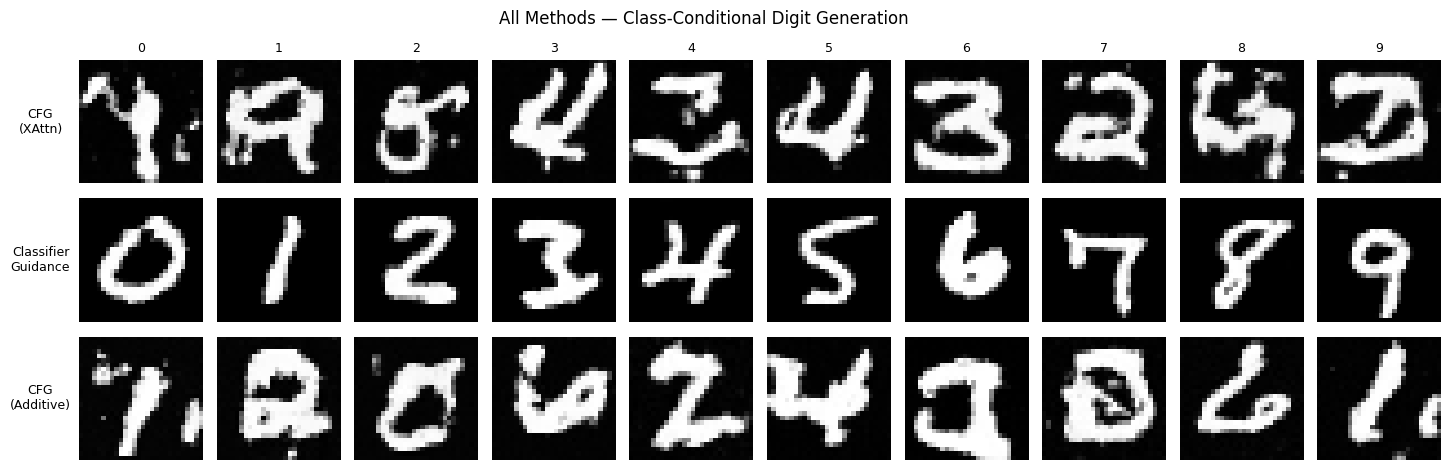

In [69]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for c in range(10):
    img_cfg = sample_cfg_ddim(model_xattn, schedule, c, w=4.0, n=1)
    img_cg = sample_classifier_guided(model_uncond, classifier, schedule, c, s=10.0, n=1)
    img_add = sample_cfg_ddim(model_additive, schedule, c, w=4.0, n=1)

    axes[0, c].imshow((img_cfg[0, 0].cpu() + 1) / 2, cmap="gray")
    axes[1, c].imshow((img_cg[0, 0].cpu() + 1) / 2, cmap="gray")
    axes[2, c].imshow((img_add[0, 0].cpu() + 1) / 2, cmap="gray")
    axes[0, c].set_title(str(c), fontsize=9)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0, 0].set_ylabel("CFG\n(XAttn)", fontsize=9, rotation=0, labelpad=28, va="center")
axes[1, 0].set_ylabel("Classifier\nGuidance", fontsize=9, rotation=0, labelpad=28, va="center")
axes[2, 0].set_ylabel("CFG\n(Additive)", fontsize=9, rotation=0, labelpad=28, va="center")

plt.suptitle("All Methods — Class-Conditional Digit Generation", fontsize=12, y=0.98)
fig.subplots_adjust(left=0.08, right=0.995, top=0.88, bottom=0.08, wspace=0.02, hspace=0.12)
plt.show()

### Timing Comparison

CFG requires 2 forward passes per step but no gradient computation. Classifier guidance requires 1 forward + 1 classifier forward+backward (gradient). The real cost difference shows up more at scale, as with large U-Nets the 2× forward of CFG is cheaper than backprop through a classifier.

In [64]:
print("Timing: 16 samples")

def time_fn(fn, label, n_runs=3):
    times = []
    for _ in range(n_runs):
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        fn()
        if device.type == "cuda": torch.cuda.synchronize()
        times.append(time.time() - t0)
    print(f"  {label}: {np.mean(times):.2f}s ± {np.std(times):.2f}s")
    return np.mean(times)

t1 = time_fn(lambda: sample_cfg_ddim(model_xattn, schedule, 5, w=4.0, n=16),
             "CFG XAttn (50 DDIM steps)")
t2 = time_fn(lambda: sample_cfg_ddim(model_additive, schedule, 5, w=4.0, n=16),
             "CFG Additive (50 DDIM steps)")
t3 = time_fn(lambda: sample_classifier_guided(model_uncond, classifier, schedule, 5, s=10.0, n=16),
             "Classifier Guidance (1000 DDPM steps)")

Timing: 16 samples
  CFG XAttn (50 DDIM steps): 0.93s ± 0.03s
  CFG Additive (50 DDIM steps): 0.71s ± 0.01s
  Classifier Guidance (1000 DDPM steps): 9.64s ± 0.05s


### Summary Table

In [65]:
print("\n" + "=" * 75)
print(f"{'Method':<28} {'Conditioning':<18} {'# Models':<14} {'Inference Cost':<15}")
print("=" * 75)
print(f"{'CFG (Additive)':<28} {'time+class sum':<18} {'1':<14} {'2× fwd/step':<15}")
print(f"{'CFG (Cross-Attn)':<28} {'cross-attention':<18} {'1':<14} {'2× fwd/step':<15}")
print(f"{'Classifier Guidance':<28} {'gradient-based':<18} {'2 (UNet+cls)':<14} {'fwd + grad/step':<15}")
print(f"{'ControlNet':<28} {'edge hints':<18} {'1 frozen+ctrl':<14} {'2× fwd/step':<15}")
print("=" * 75)


Method                       Conditioning       # Models       Inference Cost 
CFG (Additive)               time+class sum     1              2× fwd/step    
CFG (Cross-Attn)             cross-attention    1              2× fwd/step    
Classifier Guidance          gradient-based     2 (UNet+cls)   fwd + grad/step
ControlNet                   edge hints         1 frozen+ctrl  2× fwd/step    


# Results Discussion

## Classifier-Free Guidance

### Training & Conditioning Mechanism Comparison

Both CFG models (additive injection and cross-attention) converge to nearly identical final losses (~0.021), with virtually overlapping training curves. This makes sense, because for a 10-class MNIST task, class identity is a simple, low-dimensional signal, and the additive approach has more than enough capacity to convey it. The cross-attention mechanism offers strictly more expressiveness (spatially-varying conditioning), but there's simply not enough complexity in the task to exploit it. On higher-resolution, multi-object, or text-conditioned tasks the gap would widen significantly.

The additive model trains ~25% faster per epoch (0.71s vs 0.93s for 50-step DDIM sampling) because it avoids the QKV projections and attention computation at every resolution level. For class-conditional MNIST, the additive approach is clearly the better engineering choice: same quality, less compute, fewer parameters, and the U-Net body stays identical to the unconditional model from Lab 1.


### The Quality-Diversity Tradeoff

At `w=0` (pure conditional, no guidance amplification), both models generate clean, class-correct digits. This already shows that the conditioning mechanism works and that samples are diverse and recognizable.

However, as `w` increases beyond ~3.0, **class fidelity degrades rather than improves**. At `w=5` and above, we start seeing wrong-class contamination (e.g. "class 0" column showing 7s and 4s, "class 9" showing 2s). By `w=10`, heavy saturation artifacts appear, pixels get pushed to extreme black/white values, and the images lose coherence.

This is the opposite of what the CFG paper reports on ImageNet, where moderate guidance (w=2–4) consistently improves FID. The likely explanation is that **MNIST is too simple for CFG to help**. The unconditional model already generates decent digit-like images, so the gap between conditional and unconditional predictions (which CFG amplifies) is small and noisy. Amplifying a small, noisy difference mostly amplifies noise. On ImageNet, the unconditional model generates much more varied content, so the conditional-minus-unconditional direction carries a much cleaner class signal.

The cross-attention model behaves similarly: slightly better class fidelity at `w=0` (the digits look a bit crisper) but the same degradation pattern at high `w`. Again, the extra expressiveness of cross-attention doesn't buy much when the fundamental issue is that the guidance signal itself is noisy on this dataset.

### Diversity Measurement

The diversity plot shows an interesting **non-monotonic** pattern: pixel variance is lowest at `w=0` (~0.21), increases to a peak at `w=1` (~0.31), then gradually decreases back toward ~0.225 at `w=50`.

The initial increase from `w=0` to `w=1` is counterintuitive. Guidance should reduce diversity. The explanation: at `w=0` the model produces clean, class-consistent samples that happen to be quite similar to each other (the "typical" digit for that class). At `w=1`, the guidance starts pushing samples in different directions based on the noise in the conditional-vs-unconditional difference, which actually introduces more variation. As `w` continues to increase, the model saturates and collapses toward high-contrast patterns, reducing measured pixel variance.

## ControlNet

### Training

The loss starts at ~0.0165 and converges to ~0.014, notably lower than the base CFG model's ~0.021. The frozen base model is already a competent denoiser, and the Canny edges provide strong structural signal that makes the denoising task easier (the model knows where strokes should go).

### Edge-Guided Generation

The ControlNet successfully preserves the spatial structure of the input edges in the generated images. The source digit's shape, stroke positions, and overall layout are clearly maintained in the output. This confirms that the zero-conv injection mechanism works, as the control encoder learned to pass structural information through to the frozen decoder.

### Class Conditioning vs. Structural Control

Here's the key finding! **The edge structure dominates the class label**. When we condition on `cls 3` but provide edges from a `7`, the output looks like a `7`, not a `3`. This is most visible in the "Same Edges, Different Target Classes" grid: changing the target class has only subtle effects (slight thickness variations, minor stroke modifications) while the overall digit identity is determined by the edge structure.

This actually matches the original ControlNet paper's findings on natural images: structural hints like edges or depth maps are very strong conditioning signals that tend to override semantic class conditioning. On MNIST specifically, the edge map contains nearly all the information needed to reconstruct the digit, leaving little room for class conditioning to redirect the output toward a different digit shape.

The `cls 7` row shows the strongest class influence. Some digits get noticeably distorted toward 7-like features (sharper angles, straighter strokes). This makes sense because 7 is a geometrically distinctive digit with strong linear features that can be imposed without completely contradicting most edge structures.

## Classifier Guidance

### Training

The noise-aware classifier reaches ~58% accuracy averaged across all noise levels, with loss converging to ~1.15. At high noise levels (`t` close to 1000) the input is nearly pure Gaussian and classification is essentially impossible, dragging down the average. What matters is that the classifier is accurate at low noise levels where the gradient signal is most impactful during sampling.

Unconditional U-Net converges to the same ~0.021 loss as the CFG models, confirming that the U-Net architecture and training procedure are consistent across experiments.

### Scale Sweep Results

Classifier guidance produces **cleaner and more class-correct digits** than either CFG variant. At `s=0` we see random unconditional digits (confirming the base model is indeed unconditional). By `s=2`, every digit is already recognizable and correctly classified. At `s=5–10`, the digits are sharp, well-formed, and strongly class-specific. Even at `s=20`, there's minimal degradation, but the digits remain clean with only slight high-contrast sharpening.

The reason is that **the classifier gradient provides a fundamentally different kind of signal**. CFG amplifies the difference between two noise predictions, which is indirect and can be noisy. The classifier gradient directly points toward "make this look more like class Y" in pixel space, which is a much more targeted and stable signal.

## Final Comparison

### Sampling

**Classifier Guidance (s=10)** produces the cleanest, most recognizable digits across all 10 classes. Each digit is unmistakably the correct class, with natural-looking stroke patterns.

**CFG Cross-Attention (w=4)** generates blurry, often misclassified digits,several samples show clear wrong-class contamination (the "0" column shows something like a "1", the "2" column shows something unrecognizable).

**CFG Additive (w=4)** performs similarly to cross-attention, also blurry with class errors. The additive and cross-attention approaches produce roughly equivalent quality on this task, confirming that the conditioning mechanism matters less than the guidance strategy.

### Timing

CFG Additive is the fastest at 0.71s for 16 samples (50 DDIM steps), followed by CFG Cross-Attention at 0.93s (the cross-attention overhead is real but modest). Classifier Guidance is dramatically slower at 9.64s because it runs full DDPM (1000 steps) and requires a gradient computation at each step. If we implemented DDIM for classifier guidance the gap would narrow substantially, but the per-step cost would still be higher due to the backward pass through the classifier.

### What worked well?

- **Classifier guidance** is the clear winner for class-conditional generation quality on MNIST. The gradient-based steering produces sharp correctly-classified digits at moderate guidance scales.
- **CFG at w=0** (pure conditional, no guidance amplification) works well for both model variants; the conditioning mechanisms successfully teach the model to generate class-specific digits.
- **ControlNet** successfully preserves edge structure in generated images, demonstrating that the zero-conv injection pattern works even with a simple frozen base model.
- **Additive injection** matches cross-attention quality with ~25% less sampling cost, confirming it's the right choice for simple class conditioning.

### What didn't turn out as expected?

- **CFG guidance amplification hurts on MNIST**. The standard CFG formulation (increasing `w`) makes samples worse, not better. This is the most surprising result and contradicts the typical narrative around CFG.
- **ControlNet doesn't effectively override digit identity**. Conditioning on a different class while providing edges from another digit produces outputs that follow the edges, not the class.
- **The diversity-vs-guidance curve is non-monotonic**, with diversity peaking at `w=1` rather than monotonically decreasing.

### Why might results be suboptimal?

The core issue is that **MNIST is too simple** for these techniques to shine in their intended way. CFG was designed for complex, high-dimensional distributions where the gap between conditional and unconditional models is large and meaningful. On MNIST, the unconditional model already produces decent digits, and amplifying the (small, noisy) conditional signal backfires.

Similarly, ControlNet's edge maps on MNIST contain almost all the information about digit identity, leaving no room for class conditioning to redirect the output. On natural images (512×512), edges provide layout while leaving texture, color, and fine details to be determined by other conditioning.

The classifier guidance success actually confirms this reasoning: it works well precisely because it provides a direct, clean gradient signal rather than relying on amplifying a noisy difference.

### How could results be improved?

- **Lower CFG guidance scales** (`w=0.5–2.0`) would likely produce the best CFG results on MNIST, rather than the `w=3–10` range commonly used on ImageNet.
- **FashionMNIST** would be a better testbed; the 10 clothing classes have more visual overlap, making the conditional-vs-unconditional gap larger and CFG more effective.
- **DDIM for classifier guidance** would make the timing comparison much fairer (50 steps instead of 1000).
- **Thicker/dilated Canny edges** for ControlNet would provide softer structural hints, potentially giving the class conditioning more room to influence the output.
- **AdaGN conditioning** (scale + shift) could be tried as a middle ground between additive injection and cross-attention, more expressive per-channel modulation without the overhead of full attention.

# Conclusions

I implemented and compared four conditioning/guidance approaches for class-conditional diffusion on MNIST: CFG with additive injection, CFG with cross-attention, ControlNet with Canny edges, and classifier guidance.

The key takeaway is that **the right guidance strategy depends heavily on the task complexity**. Classifier guidance dominates on MNIST because its direct gradient signal is well-suited to a low-dimensional class space with simple visual distinctions. CFG's amplification-based approach, designed for complex distributions like ImageNet, actually hurts quality here because the conditional-vs-unconditional difference is small and noisy.

For the conditioning mechanism comparison, additive injection and cross-attention produce equivalent results on MNIST with the additive approach being cheaper, confirming that for simple discrete conditioning, the standard timestep-style injection is the right default. Cross-attention becomes necessary only when conditioning on variable-length sequences (text prompts) or when spatially-varying conditioning is needed.

ControlNet successfully demonstrates structural control via zero-initialized feature injection, though on MNIST the edge structure is so informative that it overrides class conditioning , but thi is a limitation of the dataset rather than the method.